In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import osmnx as ox
import networkx as nx 

## Import delimiting Polygon (& change CRS)

In [4]:
AMG_Polygon = gpd.read_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Importacion TransCAD\Limites Municipales\AMG\AMG_SHAPE.shp')

In [6]:
print(AMG_Polygon.crs)
AMG_Polygon = AMG_Polygon.to_crs(epsg=4326)
print(AMG_Polygon.crs)

EPSG:4019
EPSG:4326


In [7]:
AMG_Polygon

,ID,AREA,NOMBRE,REGI�N,CLAVE,SUP_HECT,CLAV,geometry
0,1,150.79,GUADALAJARA,CENTRO,39,15035.795856,GDL,"POLYGON ((-103.12952 20.39895, -103.12956 20.3..."


## Get Red Vial (highway) with Polygon

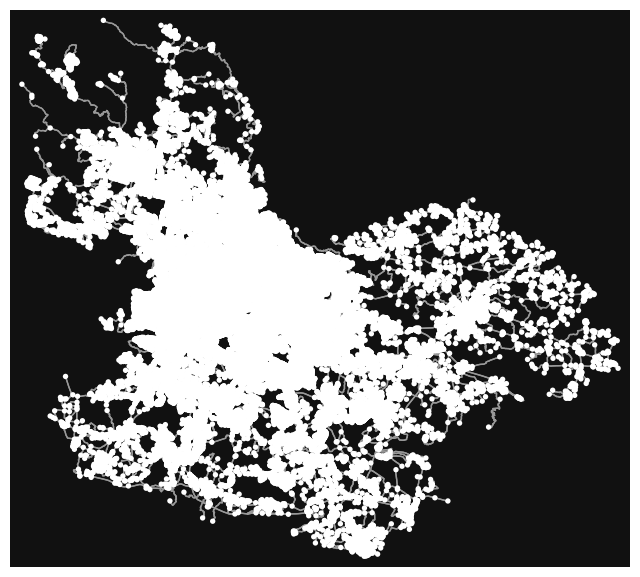

In [ ]:
G_vial = ox.graph_from_polygon(AMG_Polygon.geometry[0], network_type='drive')
fig, ax = ox.plot_graph(G_vial)

In [13]:
highway_nodes, highway_edges = ox.graph_to_gdfs(G_vial)
highway_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway\Nodes\highway_nodes.shp')
highway_edges.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway\Edges\highway_edges.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_11020\2437338892.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  highway_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway\Nodes\highway_nodes.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990913, 1135990915, 1135990925, 1135990927, 1417643155, 1417643158, 1135990936, 1135990937, 1290072088, 1249664052, 1249664053, 1249664054, 1249664055, 1249664056, 1249664058, 1249664059, 1249664061, 1249664062, 1386358746, 1386358747, 1135990877, 1135990878, 1135990879, 1135990880, 1135990887, 1135990889, 1135990901, 

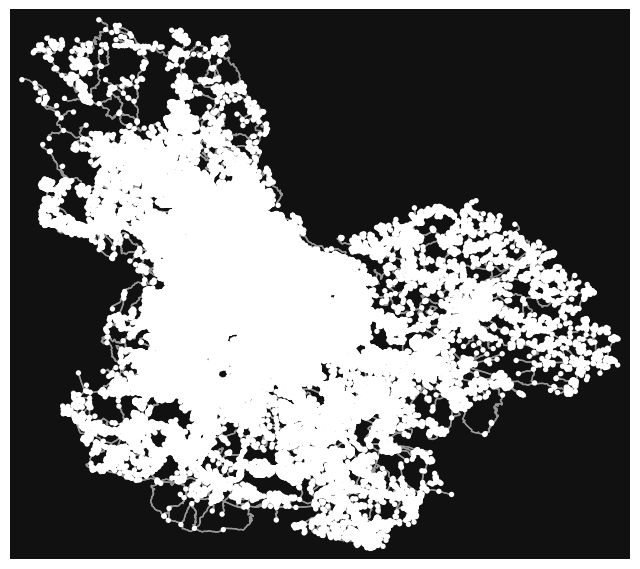

In [17]:
G_vial_all = ox.graph_from_polygon(AMG_Polygon.geometry[0], network_type='all')
fig, ax = ox.plot_graph(G_vial_all)

In [18]:
all_nodes, all_edges = ox.graph_to_gdfs(G_vial_all)
all_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway_All\Nodes\all_nodes.shp')
all_edges.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway_All\Edges\all_edges.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_11020\1381524027.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  all_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway_All\Nodes\all_nodes.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## Get Red Tren Ligero (Railway) with Polygon

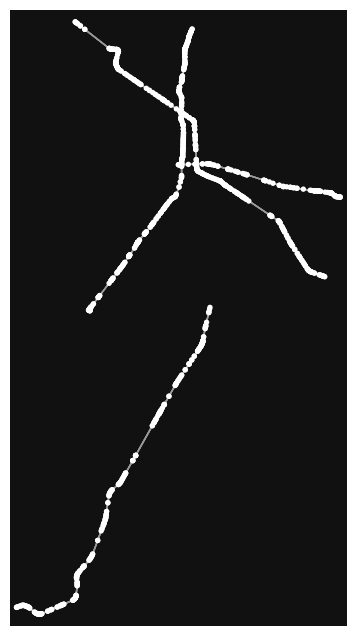

In [12]:
custom_filter = (
    '["railway"~"light_rail|subway|rail"]'
    '["name"~"Línea 1 del Tren Eléctrico Urbano|'
    'Línea 2 del Tren Eléctrico Urbano|'
    'Linea 3 del Tren Eléctrico Urbano|'
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara"]'
)
G_railway = ox.graph_from_polygon(AMG_Polygon.geometry[0], 
                                retain_all=True,
                                simplify=False,
                                custom_filter=custom_filter)
fig, ax = ox.plot_graph(G_railway)

In [14]:
railway_nodes, railway_edges = ox.graph_to_gdfs(G_railway)
railway_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Railway\Nodes\railway_nodes.shp')
railway_edges.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Railway\Edges\railway_edges.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_11020\1193152697.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  railway_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Railway\Nodes\railway_nodes.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## Get 1 graph from Highway & Railway

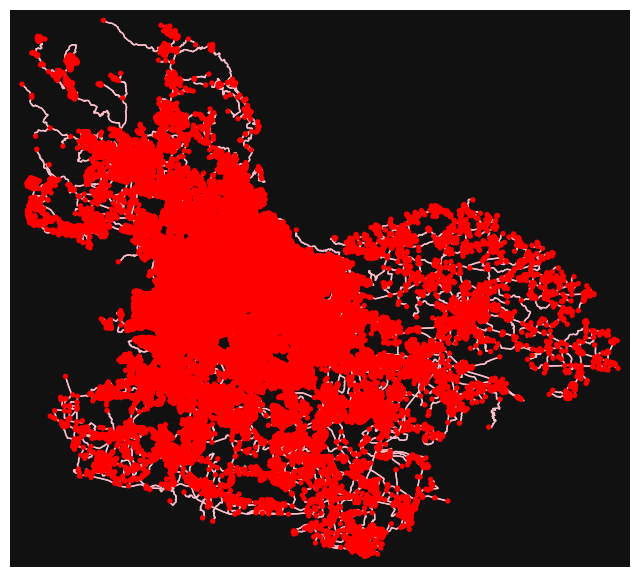

In [15]:
G_highway_railway = nx.compose(G_vial, G_railway)
fig, ax = ox.plot_graph(G_highway_railway, node_color="red", edge_color="pink")

In [16]:
combined_nodes, combined_edges = ox.graph_to_gdfs(G_highway_railway)
combined_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway-Railway\Nodes\nodes.shp')
combined_edges.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway-Railway\Edges\edges.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_11020\2020649360.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_nodes.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway-Railway\Nodes\nodes.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990913, 1135990915, 1135990925, 1135990927, 1417643155, 1417643158, 1135990936, 1135990937, 1290072088, 1249664052, 1249664053, 1249664054, 1249664055, 1249664056, 1249664058, 1249664059, 1249664061, 1249664062, 1386358746, 1386358747, 1135990877, 1135990878, 1135990879, 1135990880, 1135990887, 1135990889, 1135990901,

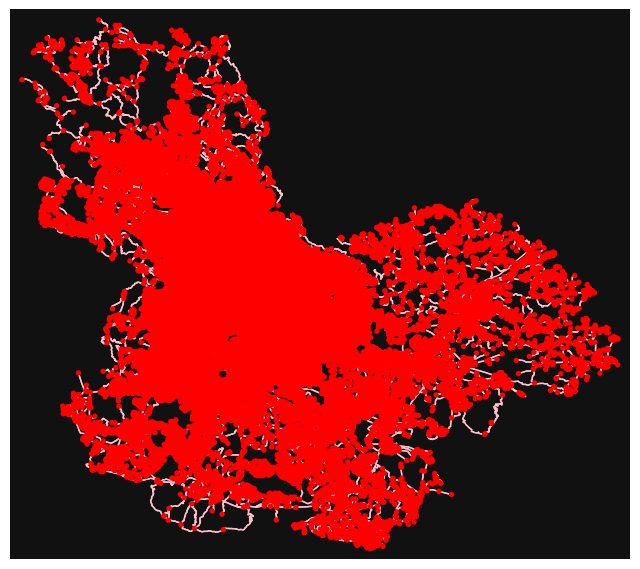

In [19]:
G_highway_all_railway = nx.compose(G_vial_all, G_railway)
fig, ax = ox.plot_graph(G_highway_all_railway, node_color="red", edge_color="pink")

In [20]:
combined_nodes_ALL, combined_edges_ALL = ox.graph_to_gdfs(G_highway_railway)
combined_nodes_ALL.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway-Railway-ALL\Nodes\nodes.shp')
combined_edges_ALL.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway-Railway-ALL\Edges\edges.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_11020\202145737.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_nodes_ALL.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Red Vial Guadalajara\Red Vial Guadalajara\Pruebas OSM-OSMNX\osmnx-AMG\Highway-Railway-ALL\Nodes\nodes.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990913, 1135990915, 1135990925, 1135990927, 1417643155, 1417643158, 1135990936, 1135990937, 1290072088, 1249664052, 1249664053, 1249664054, 1249664055, 1249664056, 1249664058, 1249664059, 1249664061, 1249664062, 1386358746, 1386358747, 1135990877, 1135990878, 1135990879, 1135990880, 1135990887, 1135990889, 1135

## __Analysis of edges__

In [21]:
combined_nodes_ALL

,y,x,street_count,highway,ref,junction,railway,geometry
osmid,,,,,,,,
267537966,20.616062,-103.246323,3,NaN,NaN,NaN,NaN,POINT (-103.24632 20.61606)
267538751,20.605647,-103.136397,3,NaN,NaN,NaN,NaN,POINT (-103.1364 20.60565)
273140976,20.607581,-103.131846,3,NaN,NaN,NaN,NaN,POINT (-103.13185 20.60758)
296347259,20.452284,-103.249527,3,NaN,NaN,NaN,NaN,POINT (-103.24953 20.45228)
296347282,20.413150,-103.232826,3,NaN,NaN,NaN,NaN,POINT (-103.23283 20.41315)
...,...,...,...,...,...,...,...,...
12837540170,20.726487,-103.353234,2,NaN,NaN,NaN,NaN,POINT (-103.35323 20.72649)
12837540171,20.723517,-103.353121,2,NaN,NaN,NaN,NaN,POINT (-103.35312 20.72352)
12837540172,20.723516,-103.353165,2,NaN,NaN,NaN,NaN,POINT (-103.35317 20.72352)
